In [1]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)
    
    size = n-2
    A = np.zeros(size)  # Subdiagonal
    B = np.zeros(size)  # Main diagonal
    C = np.zeros(size)  # Superdiagonal
    D = np.zeros(size)  # RHS
    
    for i in range(1, n-1):
        idx = i-1
        if idx > 0:
            A[idx] = h[i-1]
        
        B[idx] = 2 * (h[i-1] + h[i])
        
        if idx < size-1:
            C[idx] = h[i]
            
        D[idx] = 6 * ((y[i+1] - y[i])/h[i] - (y[i] - y[i-1])/h[i-1])
        
    return A, B, C, D

def thomas_algorithm(A, B, C, D):
    n = len(D)
    c_star = np.zeros(n)
    d_star = np.zeros(n)
    m = np.zeros(n)
    
    # Forward elimination
    c_star[0] = C[0] / B[0]
    d_star[0] = D[0] / B[0]
    
    for i in range(1, n):
        denom = B[i] - A[i] * c_star[i-1]
        if i < n - 1:
            c_star[i] = C[i] / denom
        d_star[i] = (D[i] - A[i] * d_star[i-1]) / denom
        
    # Backward substitution
    m[-1] = d_star[-1]
    for i in range(n-2, -1, -1):
        m[i] = d_star[i] - c_star[i] * m[i+1]
        
    return m

def evaluate_spline(x_points, y_points, M, x_eval):
    n = len(x_points)
    h = np.diff(x_points)
    y_eval = []
    
    for val in x_eval:
        # Here, it finds which interval val falls into
        if val <= x_points[0]:
            idx = 0
        elif val >= x_points[-2]:
            idx = n - 2
        else:
            idx = np.searchsorted(x_points, val) - 1
            
        hi = h[idx]
        xi = x_points[idx]
        xi1 = x_points[idx+1]
        Mi = M[idx]
        Mi1 = M[idx+1]
        yi = y_points[idx]
        yi1 = y_points[idx+1]
        
        term1 = Mi * (xi1 - val)**3 / (6 * hi)
        term2 = Mi1 * (val - xi)**3 / (6 * hi)
        term3 = (yi - (Mi * hi**2)/6) * (xi1 - val) / hi
        term4 = (yi1 - (Mi1 * hi**2)/6) * (val - xi) / hi
        
        y_eval.append(term1 + term2 + term3 + term4)
        
    return np.array(y_eval)

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

#Get Matrix Coefficients
A, B, C, D = setup_tridiagonal_matrix(x, y)

#Solve for interior second derivatives
M_interior = thomas_algorithm(A, B, C, D)

#Add boundary conditions (Natural Spline: M0 = Mn-1 = 0)
M = np.concatenate(([0], M_interior, [0]))

#Evaluate and Plot
x_vals = np.linspace(0, 5, 100)
y_vals = evaluate_spline(x, y, M, x_vals)

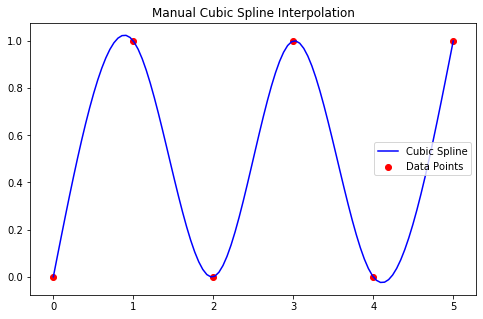

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='Cubic Spline', color='blue')
plt.scatter(x, y, color='red', label='Data Points')
plt.title("Manual Cubic Spline Interpolation")
plt.legend()
plt.show()